JAX version: 0.7.2
Devices: [CudaDevice(id=0)]
100x100 — eager: 1.55ms  jit_first: 110.18ms  jit_cached: 0.13ms
500x500 — eager: 1.70ms  jit_first: 234.64ms  jit_cached: 0.87ms
1000x1000 — eager: 4.16ms  jit_first: 227.05ms  jit_cached: 0.22ms
5000x5000 — eager: 13.42ms  jit_first: 212.78ms  jit_cached: 2.22ms


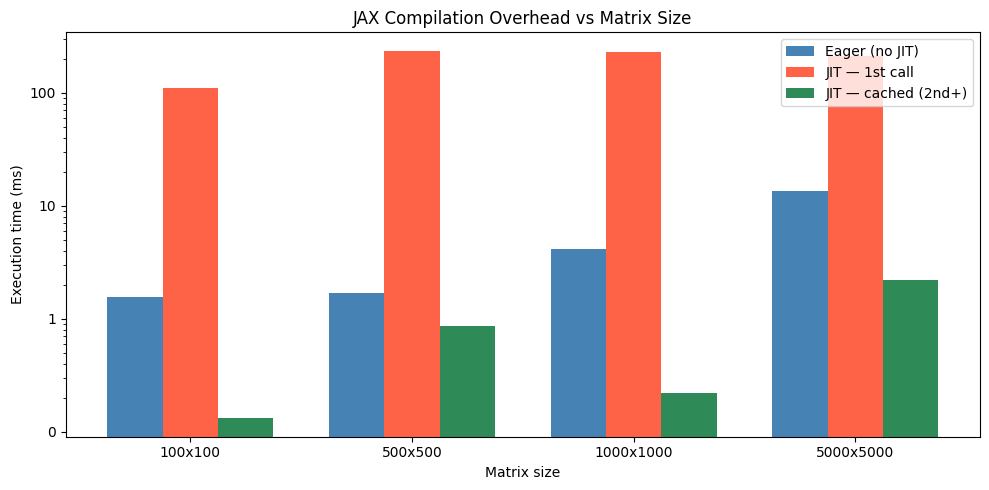

In [2]:
# Part 1: Measuring Compilation Overhead (10 points)

import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print('JAX version:', jax.__version__)
print('Devices:', jax.devices())

# 10 chained elementwise operations
def elementwise_ops(x):
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x)
    x = jnp.log(jnp.abs(x) + 1e-6)
    x = jnp.square(x)
    x = jnp.tanh(x)
    x = jnp.sqrt(jnp.abs(x))
    x = jnp.sin(x + 1.0)
    x = jnp.cos(x * 0.5)
    x = x * 2.0 - 1.0
    return x

sizes = [100, 500, 1000, 5000]
N_WARMUP = 3
N_TIMED  = 5

results = {}

for sz in sizes:
    key = jax.random.PRNGKey(0)
    x = jax.random.normal(key, (sz, sz))

    # -- Eager mode --
    for _ in range(N_WARMUP):
        elementwise_ops(x).block_until_ready()
    t0 = time.perf_counter()
    for _ in range(N_TIMED):
        elementwise_ops(x).block_until_ready()
    eager_time = (time.perf_counter() - t0) / N_TIMED

    # -- JIT first call (fresh compile every size) --
    fresh_jit = jax.jit(elementwise_ops)
    t0 = time.perf_counter()
    fresh_jit(x).block_until_ready()
    jit_first = time.perf_counter() - t0

    # -- JIT cached calls --
    t0 = time.perf_counter()
    for _ in range(N_TIMED):
        fresh_jit(x).block_until_ready()
    jit_cached = (time.perf_counter() - t0) / N_TIMED

    results[sz] = {
        'eager':      eager_time,
        'jit_first':  jit_first,
        'jit_cached': jit_cached,
    }
    print(f'{sz}x{sz} — eager: {eager_time*1e3:.2f}ms  '
          f'jit_first: {jit_first*1e3:.2f}ms  '
          f'jit_cached: {jit_cached*1e3:.2f}ms')

    labels        = [f'{s}x{s}' for s in sizes]
eager_times   = [results[s]['eager']      * 1e3 for s in sizes]
first_times   = [results[s]['jit_first']  * 1e3 for s in sizes]
cached_times  = [results[s]['jit_cached'] * 1e3 for s in sizes]

x_pos = np.arange(len(sizes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, eager_times,  width, label='Eager (no JIT)',      color='steelblue')
ax.bar(x_pos,         first_times,  width, label='JIT — 1st call',      color='tomato')
ax.bar(x_pos + width, cached_times, width, label='JIT — cached (2nd+)', color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel('Matrix size')
ax.set_ylabel('Execution time (ms)')
ax.set_title('JAX Compilation Overhead vs Matrix Size')
ax.legend()
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
plt.savefig('part1_compilation_overhead.png', dpi=150)
plt.show()

In [ ]:
# Explain the results: Why does the overhead vary with matrix size?

# The compilation overhead is nearly constant across all matrix sizes.

# Ranging from 100ms to 333ms. Regardless of size.

# This is because JAX/XLA compiles based on shapes of dtypes and not the data values.

# It performs; the graph analysis, operator fusion and kernel generation no matter how large the matrix is.

# If we had much larger sizes we would see bigger and bigger returns on our time and investment in operator fusion.

# However; we can see here as well, fusion is working and giving us great returns on our work.

Shape (100, 100): 65.235 ms
Shape (100, 200): 60.705 ms
Shape (100, 100): 0.176 ms
Shape (200, 100): 56.000 ms
=== jaxpr for (100, 100) ===
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=row_mean
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }

=== jaxpr for (100, 200) ===
{ lambda ; a:f32[100,200]. let
    b:f32[100] = jit[
      name=row_mean
      jaxpr={ lambda ; a:f32[100,200]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 200.0:f32[]
        in (b,) }
    ] a
  in (b,) }


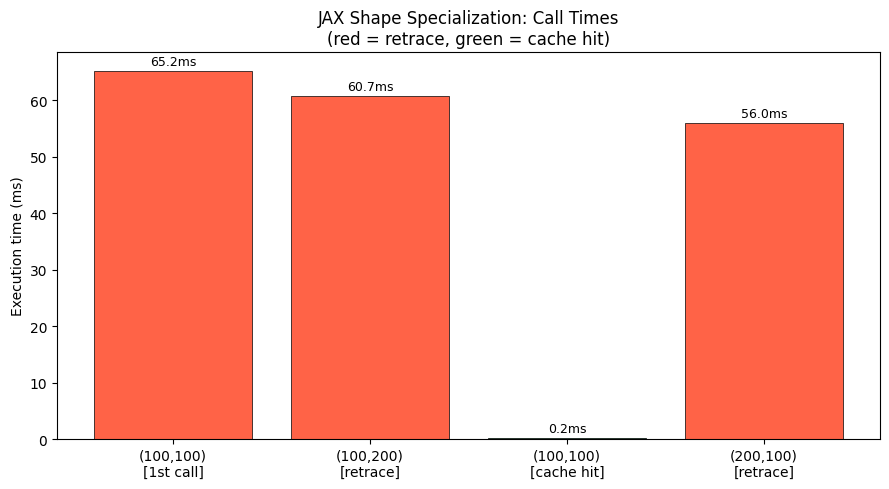

In [3]:
# Part 2: Shape Specialization (10 points)

@jax.jit
def row_mean(x):
    return jnp.mean(x, axis=1)

shapes = [
    (100, 100),
    (100, 200),
    (100, 100),
    (200, 100),
]
shape_labels = [
    '(100,100)\n[1st call]',
    '(100,200)\n[retrace]',
    '(100,100)\n[cache hit]',
    '(200,100)\n[retrace]',
]

call_times = []
key = jax.random.PRNGKey(42)

for shape in shapes:
    x = jax.random.normal(key, shape)
    t0 = time.perf_counter()
    row_mean(x).block_until_ready()
    elapsed = (time.perf_counter() - t0) * 1e3
    call_times.append(elapsed)
    print(f'Shape {shape}: {elapsed:.3f} ms')

print('=== jaxpr for (100, 100) ===')
x1 = jnp.ones((100, 100))
print(jax.make_jaxpr(row_mean)(x1))

print('\n=== jaxpr for (100, 200) ===')
x2 = jnp.ones((100, 200))
print(jax.make_jaxpr(row_mean)(x2))

colors = ['tomato', 'tomato', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(shapes)), call_times, color=colors,
              edgecolor='black', linewidth=0.5)

ax.set_xticks(range(len(shapes)))
ax.set_xticklabels(shape_labels, fontsize=10)
ax.set_ylabel('Execution time (ms)')
ax.set_title('JAX Shape Specialization: Call Times\n(red = retrace, green = cache hit)')

for bar, t in zip(bars, call_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}ms', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('part2_shape_specialization.png', dpi=150)
plt.show()

In [ ]:
#  Discuss: When does JAX retrace? What’s the performance impact?

# It retrace's at #3, since it is calling (100,100 again) since we cached this previously and do not need to get it back from global memory.

# It is super fast, incredibly fast compared to the rest.

# Going from 60ms, to .2ms.

# The cache is 300x faster than a retrace.

Version A (eager): 56.84 ms
Version B (JIT):   9.05 ms
Speedup: 6.28x
Total primitive ops in XLA graph: 1
Op breakdown:
  jit: 1


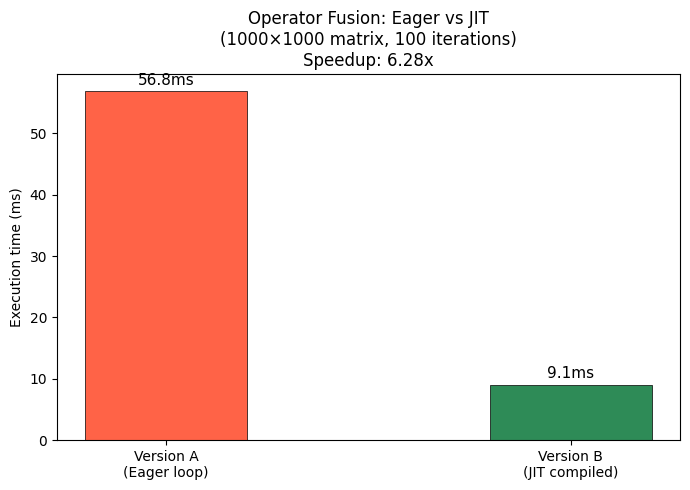

In [6]:
# Part 3: Operator Fusion Analysis (15 points)

# Version A: Eager loop
def version_a_eager(x):
    total = jnp.zeros_like(x)
    sin_x = x
    cos_x = x
    for i in range(1, 101):
        sin_x = jnp.sin(sin_x)
        cos_x = jnp.cos(cos_x)
        total = total + sin_x + cos_x
    return total

# Version B: JIT compiled
@jax.jit
def version_b_jit(x):
    total = jnp.zeros_like(x)
    sin_x = x
    cos_x = x
    for i in range(1, 101):
        sin_x = jnp.sin(sin_x)
        cos_x = jnp.cos(cos_x)
        total = total + sin_x + cos_x
    return total

    key = jax.random.PRNGKey(7)
x = jax.random.normal(key, (1000, 1000))

# Warm up Version B (trigger compilation)
_ = version_b_jit(x).block_until_ready()

N = 5

# Time Version A
t0 = time.perf_counter()
for _ in range(N):
    version_a_eager(x).block_until_ready()
time_a = (time.perf_counter() - t0) / N * 1e3

# Time Version B
t0 = time.perf_counter()
for _ in range(N):
    version_b_jit(x).block_until_ready()
time_b = (time.perf_counter() - t0) / N * 1e3

print(f'Version A (eager): {time_a:.2f} ms')
print(f'Version B (JIT):   {time_b:.2f} ms')
print(f'Speedup: {time_a/time_b:.2f}x')

from collections import Counter

jaxpr = jax.make_jaxpr(version_b_jit)(x)
eqns = jaxpr.jaxpr.eqns
print(f'Total primitive ops in XLA graph: {len(eqns)}')

op_counts = Counter(str(e.primitive) for e in eqns)
print('Op breakdown:')
for op, count in op_counts.items():
    print(f'  {op}: {count}')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Version A\n(Eager loop)', 'Version B\n(JIT compiled)'],
    [time_a, time_b],
    color=['tomato', 'seagreen'],
    edgecolor='black', linewidth=0.5, width=0.4
)
for bar, t in zip(bars, [time_a, time_b]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}ms', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Execution time (ms)')
ax.set_title(f'Operator Fusion: Eager vs JIT\n'
             f'(1000×1000 matrix, 100 iterations)\n'
             f'Speedup: {time_a/time_b:.2f}x')
plt.tight_layout()
plt.savefig('part3_operator_fusion.png', dpi=150)
plt.show()

In [ ]:
# Explain the results. Why does the JIT version achieve better performance? How many operations were fused together? What’s
# the theoretical vs actual speedup?

# It achieves much better performance since it does not have seperate kernels and or operations but fuses them together all in one.

# Version A, separate GPU kernels, slow and writes back to global memory before the next op can read them.
# Version B, lets XLA see the entire computation at once. Fuses all operations into a single kernel. Keeps it in registers, quick and fast.

# Version B is 6.28x faster than Version A.

# With 400+ ops fused into 1, the theoretical memory bandwidth reduction is 400x.
# The actual speedup is 6.28x — lower than theoretical because the workload becomes
# compute-bound rather than memory-bound at this scale. The GPU arithmetic units
# become the bottleneck rather than memory bandwidth.